```
<04_Apple_classification.ipynb>

제미나이 의존도: 40-50%

신선한 사과 34장과 상한 사과 28장을 모아서 신선한 사과 분류기를 만드는 코드입니다.
상위 디렉토리(data)를 두고, 그 안에 normal_apple, rotten_apple 폴더에 사과 사진들을 넣은 상태입니다. ImageFolder를 쓰기 위함입니다.
ImageFolder는 컴퓨터 비전용 데이터셋을 간단하게 만들 수 있는 내장 클래스입니다.

데이터 수가 너무 적기 때문에 Train/Test를 나누는 것은 사치이기 때문에, 
Train만 다뤘습니다.

Epoch [1/5] Loss: 0.5100
Epoch [2/5] Loss: 0.0828
Epoch [3/5] Loss: 0.1474
Epoch [4/5] Loss: 0.0898
Epoch [5/5] Loss: 0.0723

매 에폭마다 Loss가 줄어드는 것을 보고 행복했습니다. 되게 사소하지만요. 하지만 이제 시작입니다. 다음에는 더 많은 데이터로 다루고 싶습니다.
```

In [18]:
import glob
import os

search_pattern_normal = os.path.join('data/normal_apple', '*.jpg')
search_pattern_rotten = os.path.join('data/rotten_apple', '*.jpg')

image_paths_normal = sorted(glob.glob(search_pattern_normal))
image_paths_rotten = sorted(glob.glob(search_pattern_rotten))

print(len(image_paths_normal))
print(len(image_paths_rotten))

34
28


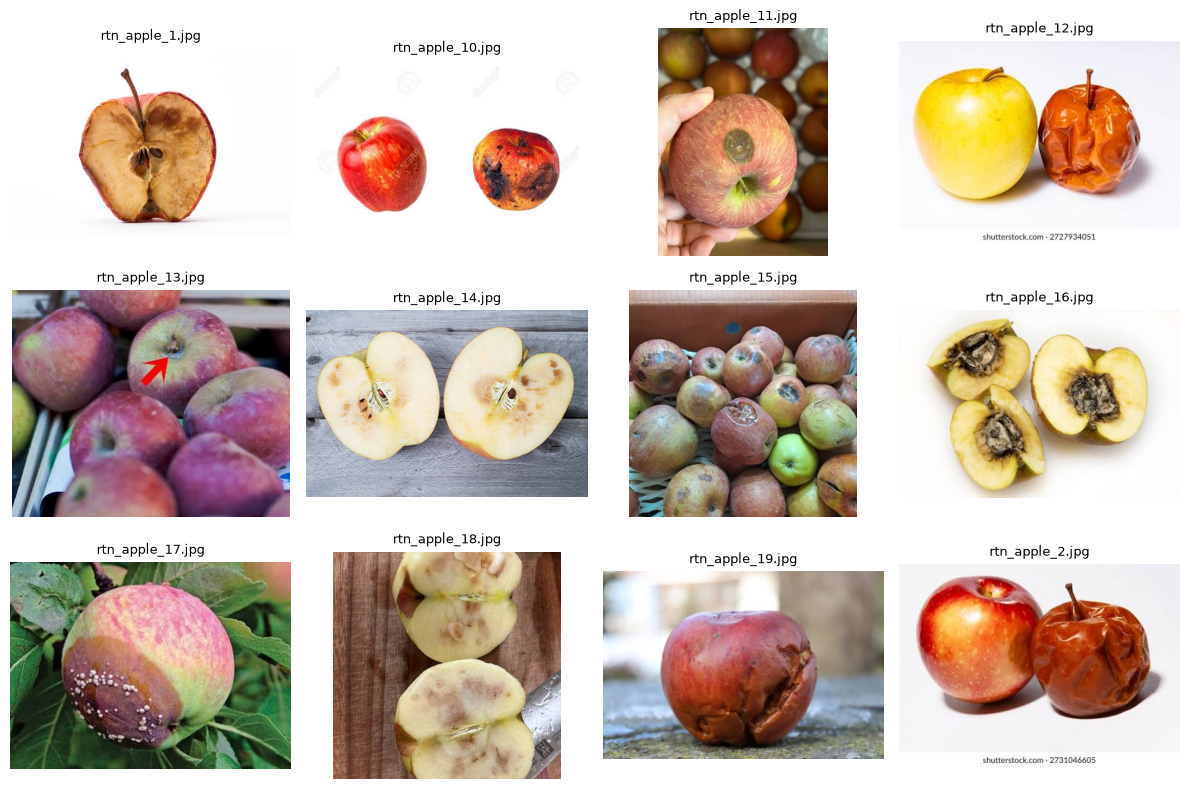

In [15]:
import matplotlib.pyplot as plt
import cv2

max_images = 12
images_to_show = image_paths_rotten[:max_images]

rows = 3
cols = 4

plt.figure(figsize=(12, 8))

for idx, path in enumerate(images_to_show):
    img = cv2.imread(path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(rows, cols, idx + 1)

    plt.imshow(img_rgb)

    plt.title(os.path.basename(path), fontsize=9)

    plt.axis('off')
plt.tight_layout()
plt.show()

In [16]:
!pwd

/Users/jeongjaehun/Crawling


In [30]:
from torchvision.datasets import ImageFolder
import torchvision.transforms as transforms

train_transform = transforms.Compose([
    transforms.Resize((128, 128)), 
    transforms.ToTensor(), 
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

dataset = ImageFolder(root="./data", transform=train_transform)
print(dataset.classes)
# print(dataset.samples)
print(dataset)
print(len(dataset))

['normal_apple', 'rotten_apple']
Dataset ImageFolder
    Number of datapoints: 82
    Root location: ./data
    StandardTransform
Transform: Compose(
               Resize(size=(128, 128), interpolation=bilinear, max_size=None, antialias=True)
               ToTensor()
               Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
           )
82


In [29]:
import pandas as pd

df = pd.DataFrame(dataset.samples, columns=['image_path', 'label'])

clean_df = df[~df['image_path'].str.contains('\.ipynb.checkpoints', na=False)]
print(clean_df['label'].value_counts())

label
0    34
1    28
Name: count, dtype: int64


In [32]:
print(clean_df)

                             image_path  label
0       ./data/normal_apple/apple_1.jpg      0
1      ./data/normal_apple/apple_10.jpg      0
2      ./data/normal_apple/apple_11.jpg      0
3      ./data/normal_apple/apple_12.jpg      0
4      ./data/normal_apple/apple_13.jpg      0
..                                  ...    ...
69  ./data/rotten_apple/rtn_apple_5.jpg      1
70  ./data/rotten_apple/rtn_apple_6.jpg      1
71  ./data/rotten_apple/rtn_apple_7.jpg      1
72  ./data/rotten_apple/rtn_apple_8.jpg      1
73  ./data/rotten_apple/rtn_apple_9.jpg      1

[62 rows x 2 columns]


In [34]:
import torch
from torch.utils.data import Dataset
from PIL import Image

class AppleDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df
        self.transform = transform
    def __len__(self):
        return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = Image.open(row['image_path']).convert('RGB')

        if self.transform:
            image = self.transform(image)
        
        label = row['label']

        return image, torch.tensor(label, dtype=torch.long)

apple_dataset = AppleDataset(df=clean_df, transform=train_transform)

In [36]:
img_tensor, label_tensor = apple_dataset[0]
print(img_tensor.shape)
print(label_tensor)

torch.Size([3, 128, 128])
tensor(0)


In [37]:
from torch.utils.data import DataLoader

train_loader = DataLoader(apple_dataset, batch_size=8, shuffle=False)

In [38]:
images, labels = next(iter(train_loader))
print(images.shape)
print(labels.shape)

torch.Size([8, 3, 128, 128])
torch.Size([8])


In [48]:
import torch.nn as nn
import torch.nn.functional as F

device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
print(f"device: {device}")

class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__() # (8, 3, 128, 128) -> (8, 8, 64, 64) -> (8, 16, 32, 32)
        self.conv1 = nn.Conv2d(3, 8, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2)
        self.conv2 = nn.Conv2d(8, 16, kernel_size=3, padding=1)
        self.fc = nn.Linear(16 * 32 * 32, 2)
    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x))) # (8, 8, 64, 64)
        x = self.pool(F.relu(self.conv2(x))) # (8, 16, 32, 32)
        x = x.view(x.size(0), -1) # (8, -1)
        x = self.fc(x)
        return x

model = SimpleCNN().to(device)

device: mps


In [49]:
import torch.optim as optim
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [50]:
epochs = 5

for epoch in range(epochs):
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch [{epoch+1}/{epochs}] Loss: {running_loss/len(train_loader.dataset):.4f}")

Epoch [1/5] Loss: 0.5100
Epoch [2/5] Loss: 0.0828
Epoch [3/5] Loss: 0.1474
Epoch [4/5] Loss: 0.0898
Epoch [5/5] Loss: 0.0723
